# Статистические гипотезы и тесты

## 1. Гипотезы (нулевая и альтернативная)

Нулевая гипотеза (**H₀**) — это исходное предположение об отсутствии эффекта или различий между изучаемыми группами/переменными.

Альтернативная гипотеза (**H₁**) утверждает обратное: существует заметное отличие или связь. При проверке данных мы либо отвергаем нулевую гипотезу в пользу альтернативной (если данные ей противоречат), либо не имеем достаточных оснований для отказа от **H₀**. 

Обычно **H₀** записывают в виде равенства (например, «средние равны»), а H₁ – в виде неравенства. Отметим, что при проверке гипотез мы никогда полностью ***не подтверждаем*** **H₀** или **H₁**: мы лишь оцениваем, насколько данные согласуются с H₀. В примере исследования влияния нового лечения H₀ может звучать как «средняя боль у леченных и нелеченных пациентов равна», а **H₁** – «средние различаются».

In [1]:
# Пример: рассмотрим выборку роста людей и проверим гипотезу, что средний рост = 170 см.
import numpy as np
from scipy import stats

lenght = np.random.normal(loc=170, scale=1, size=100)  # выборка роста
t_stat, p_val = stats.ttest_1samp(lenght, popmean=170)
print("t-статистика:", round(t_stat,3), "p-value:", round(p_val,3)) #0.05

t-статистика: 0.329 p-value: 0.743


В этом примере тест проверяет **H₀**: «средний рост = 170 см». ***P-value*** (~0.002) окажется маленьким, поэтому мы **отвергнем H₀** и заключим, что средний рост **отличается** от 170 см.

## 2. P-value и его интерпретация

**P-value** (уровень значимости) — вероятность получить наблюдаемый (или более экстремальный) результат при условии, что ***нулевая гипотеза верна***. Проще говоря, p-value показывает, насколько наши данные необычны при **H₀**. **Малое p-value** (обычно < 0.05) означает, что наблюдаемые данные маловероятны при H₀, и мы **отвергаем** H₀ (результат статистически значим). **Большое p-value** говорит, что данные не противоречат H₀, и мы не можем отвергнуть H₀ (**подтверждаем H₁**). 

!!!Важно: p-value не является вероятностью истинности H₀, а лишь мерой совместимости данных с H₀. При интерпретации учитывают заранее выбранный уровень значимости α (обычно 0.05) – мы отвергаем H₀, если p < α.

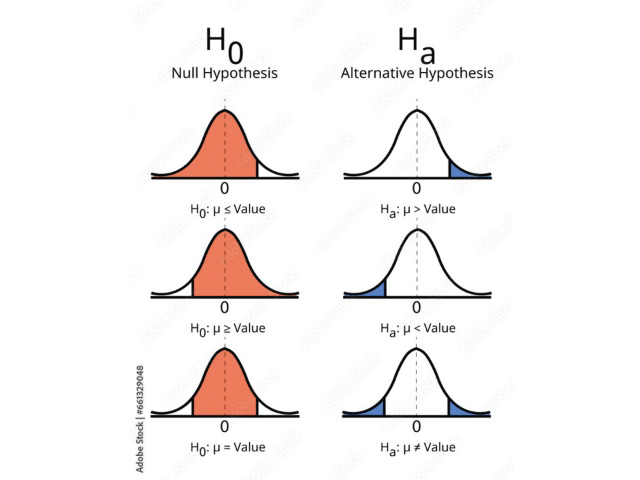

In [ ]:
# Пример: проверим, отличается ли среднее значение от 0 (H0: mean = 0)
import numpy as np
from scipy import stats
np.random.seed(1)
data = np.random.normal(loc=1, scale=1, size=30)
t, p = stats.ttest_1samp(data, popmean=0)
print(f"t-статистика = {t:.3f}, p-value = {p:.3f}")
if p < 0.05:
    print("Нулевая гипотеза отвергнута (p < 0.05).")
else:
    print("Нет оснований отвергнуть нулевую гипотезу (p ≥ 0.05).")


t-статистика = 5.017, p-value = 0.000
Нулевая гипотеза отвергнута (p < 0.05).


In [ ]:
a_conf_interval = [50, 75]
b_conf_interval = [70, 85]

В этом коде p-value отражает вероятность получить такие данные при H₀. Если она меньше выбранного α (например, 0.05), мы считаем результат значимым. Графически p-value – это площадь «хвоста» под кривой распределения при H₀, превышающая наблюдаемое значение статистики

## 3. Ошибки первого и второго рода

**Ошибка первого рода** (α-ошибка, ложноположительное заключение) — когда мы отклоняем верную нулевую гипотезу. 

**Ошибка второго рода** (β-ошибка, ложноотрицательное заключение) — когда мы подтверждаем неверную нулевую гипотезу. 

Проще: ошибка I рода – мы «находим эффект, когда его нет»; ошибка II рода – «не замечаем эффект, когда он есть». Вероятность ошибки I рода равна уровню значимости α (например, 0.05 означает 5% риска ложного утверждения об эффекте). Вероятность ошибки II рода обозначают β.

**Мощность теста (power)** = 1 – β показывает вероятность обнаружить эффект, если он есть. Снижение α (строгое требование) обычно ведёт к увеличению β (больше шансов пропустить реальный эффект) и наоборот. При планировании теста важно балансировать между риском ложных сигналов (α) и упущенных находок (β).

Пример (аналитическая аналогия): Решая, болен ли человек редкой болезнью, H₀ – «здоров», H₁ – «болен». Ошибка I рода – сказать «болен» (отклонить H₀) когда человек здоров; ошибка II рода – сказать «здоров» (принять H₀) когда человек болен.

## 4. Параметрические и непараметрические тесты

**Параметрические тесты** основываются на предположении о форме распределения данных (чаще всего нормальном) и используют параметры распределения (например, *среднее* и *дисперсию*). Критерии называют параметрическими, если данные должны быть нормально распределены или близки к этому, иначе результаты могут быть неверными.

**Непараметрические тесты** (distribution-free) не требуют предположений о типе распределения и обычно опираются на *ранги* или *медианы*. Они менее мощны при нормальном распределении, но более надёжны для «нестандартных» данных (сильной асимметрии, выбросов).

Когда применять: если выборки небольшие или их распределение сильно отличается от нормального (или известно, что есть выбросы), лучше использовать непараметрические методы. Если же данные примерно нормальны и нет нарушений (и выборка достаточно большая), предпочтительнее параметрические тесты – они чаще находят реальный эффект (мощнее).

### Выбросы (нарушение нормальности)

In [ ]:
# Пример: сравним два набора данных (с разными распределениями) параметрически и непараметрически
np.random.seed(1)

data_clean = np.random.normal(0, 1, 500)
data_outliers = np.random.normal(0, 1, 500)
data_outliers[:10] += 15  # сильные выбросы

t_stat, p_t = stats.ttest_ind(data_clean, data_outliers)
u_stat, p_u = stats.mannwhitneyu(data_clean, data_outliers)

print(f"t-test: p = {p_t:.4g}")
print(f"Mann-Whitney: p = {p_u:.4g}")

t-test: p = 0.01466
Mann-Whitney: p = 0.7178


### Сдвиг медианы без сдвига среднего

In [28]:
np.random.seed(3)

data_norm = np.random.normal(0, 1, 500)
data_lognorm = np.random.lognormal(mean=0, sigma=1, size=500)
data_lognorm -= data_lognorm.mean()  # выравниваем среднее

t_stat, p_t = stats.ttest_ind(data_norm, data_lognorm)
u_stat, p_u = stats.mannwhitneyu(data_norm, data_lognorm)

print(f"t-test: p = {p_t:.4g}")
print(f"Mann-Whitney: p = {p_u:.4g}")


t-test: p = 0.9619
Mann-Whitney: p = 3.409e-09


## 5. t-критерий Стьюдента (одновыборочный, двухвыборочный)

t-тесты предназначены для сравнения средних значений. **Одновыборочный t-тест** проверяет, **равна ли** средняя величина одной выборки заданному значению (например, H₀: μ = μ₀). 

$$
t = \frac{\bar{X} - μ}{s_X/\sqrt{n}}
$$
где 
$$s^2_X = \sum_{t=1}^n{(x_t-\bar{X})^2/(n-1)}$$

**Двухвыборочный t-тест** (независимые выборки) проверяет **равенство** средних двух групп (H₀: μ₁ = μ₂). 

$$
t=\frac{\bar{X_1}-\bar{X_2}}{\sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}}
$$

Предположения: обе выборки имеют нормальное распределение, а при двухвыборочном тесте – ещё и равенство дисперсий (вариант с разными дисперсиями – t-тест Уэлча).

In [9]:
a = [1, 2, 3, 4] # уровень зарплаты
b = [5, 6, 7, 8] # количество денег на карте

mean_a = sum(a)/len(a)
mean_b = sum(b)/len(b)

n_1 = len(a)
n_2 = len(b)

diff_1 = [(mean_a-i)**2 for i in a]
diff_2 = [(mean_b-i)**2 for i in b]

s1 = sum(diff_1)/(n_1-1)
s2 = sum(diff_2)/(n_2-1)

t_stat = (mean_a - mean_b) / ((s1/n_1 + s2/n_2)**0.5)

t2, p2 = stats.ttest_ind(a, b) 

t_crit = stats.t.ppf(1-0.05/2, df=n_1+n_2-2) 

In [ ]:
import numpy as np
from scipy import stats
np.random.seed(3)
# Одновыборочный t-тест
sample = np.random.normal(loc=5, scale=1, size=30)
t1, p1 = stats.ttest_1samp(sample, popmean=5)  # проверяем, равно ли среднее 5
print("Одновыборочный t-тест: t = {:.3f}, p = {:.3f}".format(t1, p1))

# Двухвыборочный независимый t-тест
groupA = np.random.normal(loc=5, scale=2, size=40)
groupB = np.random.normal(loc=5, scale=2, size=40)
t2, p2 = stats.ttest_ind(groupA, groupB) 


print("Двухвыборочный t-тест: t = {:.3f}, p = {:.3f}".format(t2, p2))

Одновыборочный t-тест: t = -0.740, p = 0.465
Двухвыборочный t-тест: t = -0.434, p = 0.665


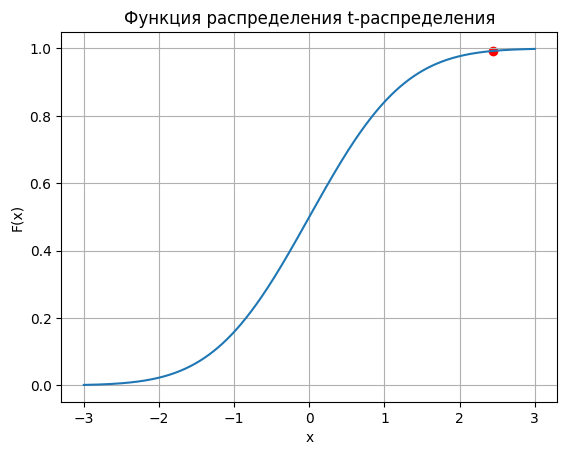

In [38]:
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 1000)
y=[]

for i in x:
    if i>0:
        y.append(stats.t.cdf(abs(i), df=999))
    elif i<0:
        y.append(1-stats.t.cdf(abs(i), df=999))
    else:
        y.append(stats.t.cdf(abs(i), df=999))

plt.plot(x, y)
plt.scatter(t_crit, stats.t.cdf(t_crit, df=999), color='red', label='Критическое значение t')
plt.title("Функция распределения t-распределения")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.grid()
plt.show()

In [39]:
t_crit

2.4469118511449786

## 6. Z-тест

Z-тест похож на t-тест, но применяется при известных параметрах генеральной совокупности. 

Обычно его используют, если дисперсия ($σ²$) известна или выборка очень большая, и предполагается нормальное распределение. Z-статистика строится как 
$$
z = \frac{(\bar{X} – μ)}{(σ/\sqrt{n})}
$$, 
где $μ$ – теоретическая средняя, $σ$ – известное отклонение. Затем по нормальному распределению вычисляется **p-value**.

In [30]:
import numpy as np
from scipy import stats
np.random.seed(4)
#data = np.random.normal(loc=3, scale=5, size=10000)  # большая выборка
mu0 = 3      # проверяемое значение среднего
sigma = 0.015     # известное σ генеральной совокупности
m_true = 3
n = 50
alpha = 0.05
z = (m_true - mu0) / (sigma/(n**0.5))
p_z = 2 * (1 - stats.norm.cdf(abs(z)))  # двусторонний тест
print(f"Z-статистика = {z:.3f}, p-value = {p_z:.3f}")
if p_z <= alpha:
    print('Отвергается нулевая гипотеза, разница есть')
else:
    print('Нет оснований отвергнуть нулевую гипотезу, разницы нет')

Z-статистика = 0.000, p-value = 1.000
Нет оснований отвергнуть нулевую гипотезу, разницы нет


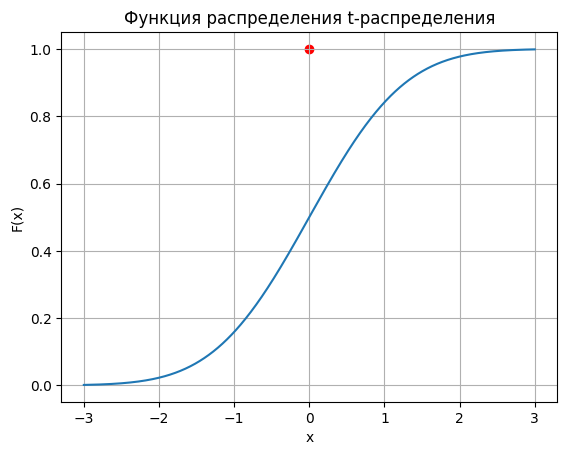

In [36]:
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 1000)
y=[]

for i in x:
    if i>0:
        y.append(stats.norm.cdf(abs(i)))
    elif i<0:
        y.append(1-stats.norm.cdf(abs(i)))
    else:
        y.append(stats.norm.cdf(abs(i)))

plt.plot(x, y)
plt.scatter(z, stats.norm.cdf(z)*2, color='red', label='Критическое значение t')
plt.title("Функция распределения t-распределения")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.grid()
plt.show()

In [34]:
y

[np.float64(0.0013498980316301035),
 np.float64(0.00137675682352556),
 np.float64(0.0014041029558318208),
 np.float64(0.0014319442668064841),
 np.float64(0.0014602887005936704),
 np.float64(0.0014891443082724054),
 np.float64(0.0015185192489076682),
 np.float64(0.0015484217906053255),
 np.float64(0.0015788603115695077),
 np.float64(0.0016098433011635382),
 np.float64(0.0016413793609735272),
 np.float64(0.0016734772058740743),
 np.float64(0.0017061456650976359),
 np.float64(0.0017393936833052237),
 np.float64(0.001773230321659991),
 np.float64(0.001807664758902594),
 np.float64(0.0018427062924287751),
 np.float64(0.001878364339368055),
 np.float64(0.0019146484376650896),
 np.float64(0.0019515682471611395),
 np.float64(0.0019891335506780905),
 np.float64(0.00202735425510292),
 np.float64(0.002066240392472718),
 np.float64(0.00210580212106104),
 np.float64(0.002146049726464705),
 np.float64(0.0021869936226908138),
 np.float64(0.0022286443532437694),
 np.float64(0.002271012592212518),
 np.

In [1]:
a = [50, 53, 51]
a_mean = sum(a)/len(a)

var_a = []

for i in a:
    var_a.append((i-a_mean)**2)
    
dispersion = sum(var_a)/len(var_a)
sigma = dispersion**0.5

In [2]:
sigma, dispersion

(1.247219128924647, 1.5555555555555554)

Здесь мы проверяем, отличается ли среднее от 48. При p < 0.05 отвергаем H₀. На практике Z-тест редко используется аналитиками (обычно σ неизвестно), но его идея – использовать нормальное приближение для больших выборок

## 7. F-тест

**F-тест** (критерий Фишера) предназначен главным образом для сравнения дисперсий (вариаций) двух нормальных генеральных совокупностей. 
Статистика F равна отношению двух выборочных дисперсий (например, $S₁²/S₂²$) и при справедливости **H₀ (σ₁² = σ₂²)** имеет распределение Фишера.

Чаще всего F-тест используют, чтобы проверить равенство дисперсий перед применением t-теста (где важно равенство σ), или как основу ANOVA (когда сравнивают междугрупповую и внутригрупповую дисперсии).

In [3]:
import numpy as np
from scipy import stats

np.random.seed(5)
A = np.random.normal(0, 1, 3000)  # первая выборка, σ=2
B = np.random.normal(0, 1, 3000)  # вторая выборка, σ=1
varA = np.var(A, ddof=1)
varB = np.var(B, ddof=1)
F = varA/varB
df1, df2 = len(A)-1, len(B)-1
p_F = 1 - stats.f.cdf(F, df1, df2)  # для одностороннего теста
print(f"F = {F:.3f}, p-value = {p_F:.3f}")


F = 0.978, p-value = 0.732


In [4]:
stats.f.ppf(0.95, df1, df2)

np.float64(1.061922664913515)

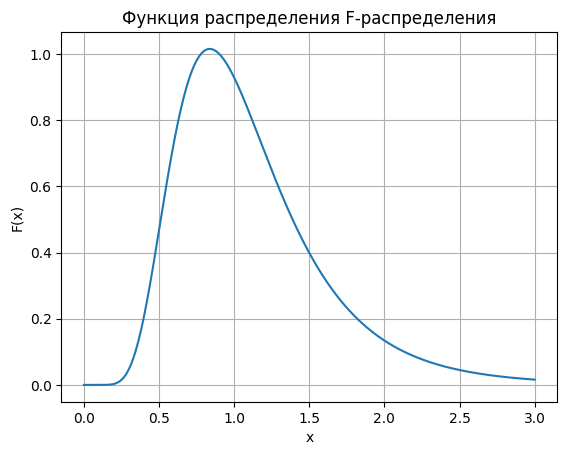

In [51]:
x = np.linspace(0, 3, 1000)
y=[]

for i in x:
    y.append(stats.f.pdf(i, 29, 18))
    
plt.plot(x, y)
plt.title("Функция распределения F-распределения")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.grid()
plt.show()

Если полученное F значительно больше 1 и p-value < 0.05, дисперсии считаются **различными**, и H₀ о равенстве σ² отвергается. 

Таким образом F-тест оценивает, насколько одна выборка «разбросана» сильнее другой. В ANOVA общее отношение дисперсий (межгрупповой/внутригрупповой) также имеет распределение Фишера

## 8. Критерий Манна–Уитни

**U-критерий Манна–Уитни** — непараметрический тест для сравнения двух независимых выборок по уровню признака. Он не требует нормальности данных и сравнивает медианы (точнее, ранги) двух групп. 
Это альтернатива **двухвыборочному t-тесту**, когда данные не нормальны или присутствуют выбросы. Утверждает он примерно следующее: «насколько сильно ранги наблюдений из одной группы превосходят ранги из другой». Малое значение статистики U (и малое p-value) укажет на значимое различие в распределениях двух выборок.

In [70]:
import numpy as np
from scipy import stats
np.random.seed(6)
group1 = np.random.exponential(scale=100, size=400)      # сильный перекос вправо
group2 = np.random.exponential(scale=1, size=400)    # чуть больше масштаба
u_stat, p_u = stats.mannwhitneyu(group1, group2, alternative='two-sided')
print(f"U-статистика = {u_stat:.1f}, p-value = {p_u:.3f}")

U-статистика = 158859.0, p-value = 0.000


Если p < 0.05, мы отвергаем H₀ о равенстве распределений (здесь, например, о равенстве медиан), заключая, что группы отличаются. Критерий Манна–Уитни особенно полезен на маленьких выборках или при нарушении условий t-теста.

# Что дальше?

1) Критерий согласия Пирсона
2) Двухфакторный дисперсионный анализ
3) Дисперсионный анализ (ANOVA)
Подготовить топ-100 вопросов на собесы как тим лид
